# Finger IMU — toolkit

Only the **functions**. No experiments, no plots, no validation narrative — those
live in [`finger_imu_practice.ipynb`](finger_imu_practice.ipynb) and in
[`docs/theory/finger_imu_ekf.md`](../docs/theory/finger_imu_ekf.md).

This notebook is the starting point for writing a *new* test from zero: run it
top to bottom and you have the three compiled models, `f/F/h/H`, `Q`/`R`, the
EKF, the plant runner and the tip kinematics available as plain callables. The
last section is a smoke test you can delete.

Nothing here is part of the `erp` package.

**Order matters** — later cells use names defined earlier.

| § | contents |
|---|---|
| 1 | XML template → the three compiled models |
| 2 | sensor indexing (`sensor_slice`, `rows_of`) |
| 3 | state ↔ `MjData`, and `f`, `F`, `h`, `H` |
| 4 | linearisation at an operating point (`A`, `B`, `C`, `D`) |
| 5 | noise: `make_spd`, `make_Q`, `make_Q_blind`, `make_R`, `sensor_noise` |
| 6 | reference trajectory + plant rollout |
| 7 | the EKF, `blind_reference`, `run_filter`, `report` |
| 8 | fingertip kinematics and covariance propagation |
| 9 | smoke test (deletable) |

In [21]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import mujoco as mj

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. Model parameters and the XML template

`assets/finger_2link.xml` is a **`str.format` template, not a loadable XML**.
Every number with physical meaning lives in the dicts below; the XML holds only
topology and the slots those values go into. `mj.MjModel.from_xml_path` on it
fails by design — go through `build_xml()`.

Three models come out of the one template, and the *only* difference between
them is the servo's internal dynamics:

| | `model_sim` (plant) | `model_blind` (filter) | `model_cut` (falsification) |
|---|---|---|---|
| `dyntype` | `filterexact`, `tau = 4 ms` | `integrator` | none |
| activation under `ctrl = 0` | — (it receives `u`) | $\dot a = 0$ → **random walk** | does not exist |
| `nx = 2 n_v + n_a` | **6** — $[q, v, a]$ | **6** | **4** — $[q, v]$ |
| role | truth + synthetic IMU | the filter being defended | falsification |

Re-filling the template also beats parsing the XML and deleting
`dyntype`/`dynprm` with `ElementTree`: `actrange` and `actearly` are only legal
when an activation state exists, so an attribute-stripping pass has to know to
remove those too or compilation fails.

In [22]:
# Import de las funciones necesarias
from erp.io.paths import resolve_model_path
from erp.core.linalg import make_spd, nees_of

XML_RELATIVE_PATH = Path("finger_2link.xml")

model_path = resolve_model_path(XML_RELATIVE_PATH)
# encoding explicito: no depender del locale. Es un TEMPLATE, no se puede cargar
# con mj.MjModel.from_xml_path -> hay que pasarlo por build_xml().
xml_template = model_path.read_text(encoding="utf-8")
print(f"Template MuJoCo: {model_path}")

Template MuJoCo: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\notebooks\assets\finger_2link.xml


In [23]:
from erp.models.finger_config import FingerRobotConfig
from dataclasses import asdict

# Instantiate the single source of truth
config = FingerRobotConfig()

# If your template builder requires dictionaries:
geometry_dict = asdict(config.geometry)
sim_options_dict = asdict(config.sim_options)

In [24]:
def build_xml(config: FingerRobotConfig, xml_template: str, motor_dyn: str) -> str:
    """Rellena el template usando la configuracion inyectada."""
    # Extraer diccionarios de la configuracion
    geometry = asdict(config.geometry)
    sim_options = asdict(config.sim_options)
    
    fields = dict(geometry, **sim_options)

    for joint_name, joint in config.joints.items():
        lo_deg, hi_deg = joint["range_deg"]
        fields[f"{joint_name}_range_deg"] = f"{lo_deg} {hi_deg}"

    for idx, (act_name, act) in enumerate(config.actuators.items(), start=1):
        lo, hi = np.deg2rad(config.joints[act.joint]["range_deg"])
        
        fields[f"{act_name}_ctrlrange"] = f"{lo:.6f} {hi:.6f}"
        fields[f"{act_name}_forcerange"] = f"{-act.force_max} {act.force_max}"
        fields[f"{act_name}_armature"] = act.armature
        fields[f"{act_name}_damping"] = act.damping
        fields[f"{act_name}_gainprm"] = f"{act.kp} 0 0"
        fields[f"{act_name}_biasprm"] = f"0 {-act.kp} {-act.kv}"
        
        if motor_dyn == "filterexact":
            fields[f"motor_dynamics_{idx}"] = (
                f'dyntype="filterexact" dynprm="{act.tau}" actearly="true" '
                f'actrange="{lo:.6f} {hi:.6f}"')
        elif motor_dyn == "randomwalk":
            fields[f"motor_dynamics_{idx}"] = (
                f'dyntype="integrator" actearly="true" '
                f'actrange="{lo:.6f} {hi:.6f}"')
        elif motor_dyn == "none":
            fields[f"motor_dynamics_{idx}"] = ""
        else:
            raise ValueError(f"motor_dyn desconocido: {motor_dyn!r}")

    return xml_template.format(**fields)


def state_dim(m: mj.MjModel) -> int:
    return 2 * m.nv + m.na


def compile_model(config: FingerRobotConfig, xml_template: str, motor_dyn: str):
    m = mj.MjModel.from_xml_string(build_xml(config, xml_template, motor_dyn))
    return m, mj.MjData(m)

In [25]:
# --- los tres modelos -------------------------------------------------------
# Asegurate de que 'config' y 'xml_template' esten definidos antes de esta celda
model_sim,   data_sim   = compile_model(config, xml_template, "filterexact") 
model_blind, data_blind = compile_model(config, xml_template, "randomwalk")  
model_cut,   data_cut   = compile_model(config, xml_template, "none")        

dt_sim = model_sim.opt.timestep

assert state_dim(model_sim) == 6 and state_dim(model_blind) == 6
assert state_dim(model_cut) == 4
assert model_sim.nsensordata == model_blind.nsensordata == model_cut.nsensordata, \
    "Los tres modelos tienen que compartir el bloque de sensores"

for nm, m in (("model_sim", model_sim), ("model_blind", model_blind),
              ("model_cut", model_cut)):
    print(f"{nm:12} nv={m.nv} na={m.na} nu={m.nu} -> nx={state_dim(m)}, "
          f"nsensordata={m.nsensordata}")
print(f"dt = {dt_sim * 1000:.0f} ms")
print("sensores:", [model_sim.sensor(i).name for i in range(model_sim.nsensor)])

model_sim    nv=2 na=2 nu=2 -> nx=6, nsensordata=18
model_blind  nv=2 na=2 nu=2 -> nx=6, nsensordata=18
model_cut    nv=2 na=0 nu=2 -> nx=4, nsensordata=18
dt = 2 ms
sensores: ['pos_punta_seg1', 'acc_i1', 'gyro1', 'pos_c', 'acc_i2', 'gyro2']


## 2. Sensor indexing

`sensordata` is one flat vector; every filter update needs a *subset* of its
rows. `sensor_slice` maps a sensor name to its rows, `rows_of` concatenates
several into the index array `EKF.update` takes.

`IMU` is the default subset — accelerometers plus gyros. The `framepos` sensors
(`pos_c`, …) are deliberately **out**: they are free ground truth for the
fingertip, and updating on them would contaminate that check.

In [26]:
from erp.sensors.mujoco import sensor_slice, rows_of

# Define the sensor suite for this specific experiment
IMU = ("acc_i1", "gyro1", "acc_i2", "gyro2")

# Explicitly pass the model
ROWS = rows_of(model_blind, *IMU)

print(f"IMU = {ROWS.size} canales, filas {ROWS}")
for i in range(model_blind.nsensor):
    nm = model_blind.sensor(i).name
    print(f"  {nm:18} {sensor_slice(nm, model_blind)}")

IMU = 12 canales, filas [ 3  4  5  6  7  8 12 13 14 15 16 17]
  pos_punta_seg1     slice(0, 3, None)
  acc_i1             slice(3, 6, None)
  gyro1              slice(6, 9, None)
  pos_c              slice(9, 12, None)
  acc_i2             slice(12, 15, None)
  gyro2              slice(15, 18, None)


## 3. State ↔ `MjData`, and `f`, `F`, `h`, `H`

The four functions the EKF is built from. They all take `(x, u, model, data)` and
are generic in the model, so the same code runs the 4-state cut and the 6-state
blind filter.

State layout is **blocks, not interleaved**: `x = [qpos, qvel, act]`, with `act`
present only when `na > 0`.

`h` and `H` stay separate on purpose — the filter calls them at different rates.
`h` runs on every innovation (one `mj_forward`); `H` only when relinearising
(`2*nx` finite-difference evaluations). Returning both together makes you pay for
`H` every time you only wanted `z_pred`.

Three things that are easy to get wrong here, all load-bearing:

- **`h` takes `u`, not just `x`.** The accelerometers read `qacc`, and `qacc`
  depends on the servo torque, so `∂h/∂u` is nonzero for `acc_i1`/`acc_i2` and
  exactly zero for the gyros and position sensors. An innovation built as
  `z − h(x)` is biased in the accelerometer channels. (A *blind* filter passing
  `u = 0` everywhere is a modelling choice, not an omission — see § 7.)
- **`mj_forward`, not a cheaper stage.** `mjSENS_ACC` sensors are only valid
  after the acceleration stage; stopping at `mj_fwdPosition + mj_sensorPos`
  leaves `acc_i1` and `acc_i2` wrong while the other four sensors already look
  fine.
- **`H` is `mjd_transitionFD`'s `C`, not `mjd_inverseFD`'s `DsDq`.** The latter
  are partials with `(q, v, a)` held independent — they ignore `∂a/∂q`. For the
  `acc_i1_y` row that is 9.22 against a true 716.35.

Related gotcha when validating against logged data: **`mj_step` does not refresh
`sensordata`**. After a step it still holds the readings of the pre-integration
state, so a loop that logs `qpos` after the step and sensors alongside it pairs
them one step apart. Call `mj_forward` before logging sensors, or log them before
stepping — which is what `plant_run` in § 6 does.

In [27]:
from erp.sim.mujoco import f_dyn, F_dyn, h_dyn, H_dyn, state_dim, _dump

## 4. Linearisation at an operating point

`linearize` is the same `mjd_transitionFD` call returning all four blocks at
once. Use it when you want a **fixed** LTI model to test against, rather than the
per-step Jacobians the EKF takes. `C` is exactly the `H` of § 3.

Two things about using `A`, `B` outside the filter:

- **`A` is a Jacobian, so the model is in deviations**, not in absolute state:
  $x_i \approx f(x_{op}, u_{op}) + A(x_{i-1}-x_{op}) + B(u_{i-1}-u_{op})$.
  The affine term is not decoration — $x_{op}$ is generally *not* an equilibrium
  (the servo sits at rest but gravity keeps pulling), so
  $f(x_{op},u_{op}) \neq x_{op}$. That is what `affine_predict` is for.
- **Linearise on the model you will score against.** Linearising on the 4-state
  cut and scoring against the 6-state plant measures linearisation error *and*
  the 4 ms motor lag at once — two different problems with two different fixes
  (relinearise vs. inflate `Q`).

And do not trim the 6-state model to 4×4 to get the rigid-body pair. In the plant
the control enters *only* through the activations, so `B_sim[:4]` is that `B`
scaled by $1-e^{-\Delta t/\tau} \approx 0.39$, and trimming `A` throws away the
activation columns that carried the rest of the effect. The trimmed pair is a
*wrong* model, not an approximate one — compile `motor_dyn="none"` instead.

Finally: a one-step error is meaningless without a scale. At `dt = 2 ms` the
state barely moves, so *any* model — including a badly wrong one — posts a small
absolute error. Report it relative to the real per-step motion
$\lVert\Delta q\rVert$, and put a deliberately corrupted `A` through the
identical test. Note also that zeroing a *velocity* row of `A` leaves the
one-step `q` error untouched; only an open-loop rollout catches it.

In [28]:
from erp.sim.mujoco import linearize
from erp.models.linear import affine_predict

## 5. Noise: `Q`, `R`, and keeping `P` positive definite

`SIG_*` are the defaults; every builder takes them as arguments so a run can ask
for a different level **without** rebinding the module-level constant — doing
that silently changes the `R` of every later cell, including the tip propagation.

The one that does not survive a change of regime is `SIG_ACT`. With `u` visible
it means "jitter around a setpoint I know" (2e-4 rad). Blind, the same symbol has
to cover the *entire* unknown actuation — the command sweeps 45° at 0.5 Hz, i.e.
2.5e-3 rad per 2 ms step — and lands two orders higher. `make_Q_blind` exists so
the plant's value cannot be used by accident in a filter without `u`: that is the
catastrophic case (NEES 17508, 8.8 % coverage), not the conservative one.

`make_spd` is not cosmetic and every operation on `P` goes through it — see the
docstring.

In [29]:
# --- ruido de sensor y de proceso -------------------------------------------
SIG_ACC, SIG_GYR = 0.05, 0.005    # m/s^2 y rad/s, especificacion del sensor
SIG_ALPHA = 12.0                  # rad/s^2 (1 sigma): perturbacion de torque
SIG_ACT = 2e-4                    # rad, jitter de la activacion de la PLANTA:
                                  # cuanto tiembla el servo alrededor de un
                                  # setpoint que SI conoce

# --- constantes del filtro CIEGO --------------------------------------------
SIG_ACT_BLIND = 1e-2   # rad/paso. Sin u, el random walk tiene que poder seguir
                       # un comando que se mueve 2.5e-3 rad por paso de 2 ms.

# La fuerza del servo es kp*(a - q) - kv*v: depende SOLO de la diferencia. Sin u,
# correr q y a JUNTOS deja la fuerza intacta -> ese modo comun no se observa por
# la dinamica. Lo unico que lo rompe es la gravedad rotando con q, y eso vale
# 0.17 sigma de sensor contra 38.6 sigma si se mueve q sola (factor 224).
# Sin SIG_CM nada inyecta A LO LARGO de ese modo: P colapsa ahi mientras el error
# real deriva (cobertura 50.6% contra 93.4%). No es blanquear un sesgo, es
# admitir una direccion que de verdad no se observa.
SIG_CM = 1e-4          # rad/paso a lo largo del modo comun (q_j, a_j)

from erp.core.linalg import make_spd

In [30]:
from erp.sim.mujoco import make_Q
from erp.sensors.mujoco import make_R, sensor_noise

# --- ruido de sensor y de proceso -------------------------------------------
SIG_ACC, SIG_GYR = 0.05, 0.005    # m/s^2 y rad/s
SIG_ALPHA = 12.0                  # rad/s^2 (1 sigma)
SIG_ACT = 2e-4                    # rad

# --- constantes del filtro CIEGO --------------------------------------------
SIG_ACT_BLIND = 1e-2   
SIG_CM = 1e-4          

def make_Q_blind(model):
    """Wrapper that applies the blind filter tuning constants."""
    return make_Q(model, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT_BLIND, sig_cm=SIG_CM)


## 6. Reference trajectory and plant rollout

The reference is a **raised cosine** per joint, so angle *and* angular velocity
start at 0 — matching what `mj_resetData` leaves — and there is no startup
transient in the accelerometers. `ctrl` is the target **angle in radians**: the
PD loop lives in the actuator definition and MuJoCo integrates it implicitly.

`plant_run` is the ground truth. Two things it has to get right:

- **Time alignment.** `X[k]`, `Z[k]` and `U[k]` all refer to instant $t_k$, so
  the loop logs *before* `mj_step` and `X[k+1] = f(X[k], U[k])` holds exactly.
  Logging after the step while reusing the previous `u` shifts state, measurement
  and control by a full step — ~0.13° here, which is the entire per-step motion,
  and it disguises itself as model error.
- **Process noise goes on the state; sensor noise does not.** The perturbed
  trajectory *is* the real trajectory. What a sensor does is change what you read
  off it, which is `sensor_noise`'s job. Keeping the two stages separate is what
  makes `Z_true` exist as data at all.

The returned arrays are ragged on purpose: `X` and `t` have `n+1` samples, `U`
and `Z` have `n`, because the control acts *during* a step. Plot the latter two
against `t[:-1]`.

In [31]:
sine_params = {
    "joint_1": dict(amplitude=np.deg2rad(45), freq=0.5),
    "joint_2": dict(amplitude=np.deg2rad(60), freq=0.3),
}


def sine_target(p, t):
    """Coseno invertido ("raised cosine"): angulo Y velocidad arrancan en 0, o sea
    coherente con qpos=0, qvel=0 de mj_resetData -> sin pico de torque al arrancar.

        theta(t)     = A/2 (1 - cos(w t))
        theta_dot(t) = A/2 w sin(w t)

    -> (theta, theta_dot) en rad y rad/s.
    """
    w = 2 * np.pi * p["freq"]
    return (p["amplitude"] / 2 * (1 - np.cos(w * t)),
            p["amplitude"] / 2 * w * np.sin(w * t))


def reference_targets(t):
    """ctrl de los dos servos en t -> (2,) ANGULO OBJETIVO en rad, no un torque:
    la fuerza sale de kp*(act - q) - kv*v adentro de MuJoCo."""
    return np.array([sine_target(sine_params["joint_1"], t)[0],
                     sine_target(sine_params["joint_2"], t)[0]])


def plant_run(n_steps, seed, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT,
              ref=reference_targets, model=None, data=None):
    """Verdad de referencia sobre la planta, con una perturbacion CONOCIDA.

    X[k], Z[k] en el instante t_k;  U[k] actua durante [t_k, t_{k+1}].
    Se loguea ANTES de mj_step -> X[k+1] = f(X[k], U[k]) exacto. Loguear despues
    del paso reusando el u anterior corre estado/medicion/control un paso entero.

    La perturbacion se aplica como aceleracion angular sobre el paso (dt^2/2 en
    posicion, dt en velocidad), que es justo el w que describe make_Q. Va sobre el
    ESTADO a proposito: el ruido de proceso es parte de la verdad -- la trayectoria
    perturbada ES la trayectoria real. Lo que NO va aca es el ruido de sensor, que
    no cambia el estado sino lo que se lee de el -> sensor_noise().

    -> (X, Z, U, t) con len(X) = len(t) = n_steps+1 y len(Z) = len(U) = n_steps.
       Z son lecturas IDEALES, sin ruido de sensor.
    """
    model = model_sim if model is None else model
    data = data_sim if data is None else data
    dt = model.opt.timestep
    rng = np.random.default_rng(seed)
    nv = model.nv
    mj.mj_resetData(model, data)
    X, Z, U, t = [], [], [], []
    for _ in range(n_steps):
        u = ref(data.time)
        data.ctrl[:] = u
        mj.mj_forward(model, data)      # sensores evaluados en el estado ACTUAL
        X.append(_dump(model, data))
        Z.append(data.sensordata.copy())
        U.append(u)
        t.append(data.time)
        mj.mj_step(model, data)

        # Estas cuatro lineas de abajo añadian ruido directametne a la dinámica de la planta (por ahora no quiero implementar esto)
        #nu_w = rng.normal(0, sig_alpha, nv)
        #data.qpos[:nv] += dt ** 2 / 2 * nu_w
        #data.qvel[:nv] += dt * nu_w
        #data.act[:model.na] += rng.normal(0, sig_act, model.na)
    X.append(_dump(model, data))
    t.append(data.time)
    return np.array(X), np.array(Z), np.array(U), np.array(t)

## 7. The EKF

Joseph-form update, `np.linalg.solve` throughout (never an explicit inverse — `S`
reaches condition numbers ~1e11 near a stretched pose), `make_spd` after every
operation on `P`.

The filter is **blind**: `EKF.u_blind` is the only `ctrl` it ever writes, and
there is no parameter to pass a control through. That is the real situation — the
setpoint lives inside the servo's controller and the estimator does not see it.

Removing `u` is not dropping a term; it forces you to say what the filter assumes
about the actuation, and the three compiled models are the three possible
answers:

| filter model | states | what `ctrl = 0` assumes |
|---|---|---|
| `model_blind` | 6 — `[q, v, act]` | $\dot a = 0$: the activation is a **random walk** |
| `model_sim` | 6 — `[q, v, act]` | $\dot a = -a/\tau$: the activation **decays to zero** |
| `model_cut` | 4 — `[q, v]` | no activation: force $= -k_p q - k_v v$ |

Only the first is defensible. The other two are kept because a consistency test
that cannot fail proves nothing — they land at NEES 6.5e8 and 4.9e9 against the
blind filter's 41.

`run_filter`'s two non-obvious defaults, both of which cost real debugging time:

- **The activation is scored against `a_{k+1}`, not `a_k`.** The plant uses
  `actearly="true"`, so the force during step $k$ comes from the activation at
  the *end* of the step — which is exactly the state the blind filter carries.
  Scoring against `a_k` charges half a step of lag against a tiny sigma: NEES
  4448 instead of 38, a factor of 117 that is pure bookkeeping and zero physics.
  `blind_reference` is the fix.
- **`p0_act_deg = 0.5`, not 10.** At 10° the initial activation error demands
  `kp·0.175 = 0.35 N·m` against a 0.30 N·m stall torque, so the filter's own
  model starts **saturated**: the force Jacobian goes to ~0, the activation stops
  being observable and it never recovers (NIS up to 1.8e6, 40° of error). That
  reads as "the blind filter does not work" when it is the initial condition. At
  t = 0 the finger is at rest and the activation is 0, so 0.5° is legitimate.

In [32]:
from erp.estimators.ekf import EKF
from erp.sim.mujoco import f_dyn, F_dyn, h_dyn, H_dyn

In [33]:
def blind_reference(X, model):
    """Verdad contra la que se puntea un filtro ciego CON activacion.

    La planta usa actearly="true": la fuerza del paso k sale de a_{k+1}, la
    activacion del FINAL del paso. El estado del filtro ciego es la activacion en
    vigor DURANTE el paso, o sea ese mismo a_{k+1}. Comparar contra a_k cobra
    medio paso de desfasaje contra un sigma diminuto y arruina el NEES sin que
    haya nada mal en el filtro (4448 contra 38, factor 117, cero fisica). Es el
    mismo error de fondo que puntear una creencia valida en t_a contra una verdad
    en t_b.

    Los bloques q y v no se tocan. El ultimo paso no tiene a_{k+1} y se deja como
    esta -- la corrida lo descarta al cortar en len(Z).
    """
    Xr = np.array(X, dtype=float, copy=True)
    if model.na:
        Xr[:-1, 2 * model.nv:] = X[1:, 2 * model.nv:]
    return Xr


def nees_of(err, cov):
    """e^T Sigma^-1 e por muestra. solve, no inv."""
    return np.array([e @ np.linalg.solve(S, e) for e, S in zip(err, cov)])


def run_filter(model, X, Z, rows=None, seed=0, Q=None, R=None, p0_act_deg=0.5):
    """Corre el EKF CIEGO sobre una trayectoria y unas mediciones YA DADAS.

    NO recibe U, y no es que lo ignore: no hay por donde pasarlo. El unico ctrl
    del filtro es EKF.u_blind = 0.

    Z : (N, nsensordata) mediciones tal cual las consume el filtro. Esta funcion
        NO les agrega ruido -- eso lo hizo sensor_noise() antes. Asi dos modelos
        distintos ven exactamente la misma realizacion.
    Q, R : estadisticas que ASUME el filtro. Pasarlas explicitas cuando la planta
        corrio con otras, si no el NEES mide el desajuste de Q y no el del modelo.
        Para un filtro sin u va make_Q_blind(model), NO make_Q(model).
    seed : solo el error inicial; el ruido de medicion ya no sale de aca.
    p0_act_deg : sigma inicial de la activacion en grados. NO es un parametro
        libre -- ver la celda markdown de arriba.

    -> dict, una fila por paso arrancando en k = 1:
       nees, nis, err (X - x_hat), sig (sqrt(diag(P))), xh (x_hat a posteriori),
       innov (z - h(x_pred)), z_pred (h(x_pred): lo que el filtro creia que iba a
       leer),
       mas nx / model / rows para que report() no necesite recibirlos.
    """
    rows = ROWS if rows is None else rows
    nx = state_dim(model)
    data = mj.MjData(model)
    rng = np.random.default_rng(seed)
    Q = make_Q(model, SIG_ALPHA, SIG_ACT) if Q is None else Q
    R = make_R(model, SIG_ACC, SIG_GYR) if R is None else R
    P0 = np.diag(([np.deg2rad(3) ** 2] * 2 + [np.deg2rad(15) ** 2] * 2
                  + [np.deg2rad(p0_act_deg) ** 2] * 2)[:nx])
    Xr = blind_reference(X, model)   # activacion en vigor durante el paso
    ekf = EKF(Xr[0, :nx] + rng.multivariate_normal(np.zeros(nx), P0),
              P0, Q, R, model, data)
    keys = ("nees", "nis", "err", "sig", "xh", "innov", "z_pred")
    out = {k: [] for k in keys}
    for k in range(1, len(Z)):
        ekf.predict()                      # t_{k-1} -> t_k, sin control
        y, nis_k = ekf.update(Z[k], rows)  # medicion de t_k, ya ruidosa
        e = Xr[k, :nx] - ekf.x
        out["nees"].append(float(e @ np.linalg.solve(ekf.P, e)))
        out["nis"].append(nis_k)
        out["err"].append(e)
        out["sig"].append(np.sqrt(np.diag(ekf.P)))
        out["xh"].append(ekf.x.copy())
        out["innov"].append(y)
        out["z_pred"].append(Z[k, rows] - y)        # z - (z - h) = h(x_pred)
    d = {k: np.array(v) for k, v in out.items()}
    d["nx"], d["model"], d["rows"] = nx, model, rows
    return d


def report(label, d, X, Z_ideal=None, sig_acc=SIG_ACC):
    """Veredicto de una corrida: NEES/NIS/RMS/cobertura sobre la segunda mitad
    (la primera esta dominada por el transitorio de convergencia de P0).

    El NEES se reporta como MEDIANA a proposito: la distribucion tiene cola pesada
    (percentil 99 varios ordenes sobre la mediana) por momentos breves en que P es
    chica y la linealizacion es mala.

    El sesgo de medicion, si se pasa Z_ideal, se mide contra la lectura IDEAL y no
    contra la ruidosa: lo que se busca es el sesgo DETERMINISTICO de h, y el ruido
    de sensor solo lo taparia con varianza. Q describe ruido blanco de media cero,
    asi que puede ensanchar P pero NUNCA sacar un sesgo de h.
    """
    model, nx, rows = d["model"], d["nx"], d["rows"]
    half = len(d["nees"]) // 2
    cov = (np.abs(d["err"][half:]) <= 2 * d["sig"][half:]).mean()
    print(f"\n===== {label} =====")
    if Z_ideal is not None:
        Xr = blind_reference(X, model)
        dm = mj.MjData(model)
        bias = np.array([Z_ideal[k] - h_dyn(Xr[k, :nx], np.zeros(model.nu), model, dm)
                         for k in range(0, len(Z_ideal) - 1, 25)])
        a2 = sensor_slice("acc_i2", model).start + 1
        print(f"  sesgo de medicion |acc_i2_y| = {np.abs(bias[:, a2]).mean():12.4f} m/s^2  "
              f"(sigma sensor {sig_acc})")
    print(f"  NEES  mediana = {np.median(d['nees'][half:]):14.2f}   (objetivo {nx})")
    print(f"  NIS   media   = {d['nis'][half:].mean():14.2f}   (objetivo {len(rows)})")
    print(f"  RMS q = {np.rad2deg(d['err'][half:, :2]).std(axis=0)} deg    "
          f"sigma_P = {np.rad2deg(d['sig'][half:, :2].mean(axis=0))} deg")
    print(f"  RMS v = {np.rad2deg(d['err'][half:, 2:4]).std(axis=0)} deg/s  "
          f"sigma_P = {np.rad2deg(d['sig'][half:, 2:4].mean(axis=0))} deg/s")
    print(f"  cobertura banda 2sigma = {cov:6.1%}   (nominal 95%)")

## 8. Fingertip kinematics

The filter estimates `[q1, q2, …]`; `fk_tip` turns those joint angles into the
fingertip position, and `fk_tip_jacobian` gives $J = \partial(y,z)/\partial(q_1,q_2)$.

Both hinges have `axis="1 0 0"`, so the finger moves in the y–z plane and
$R_x(\theta)[0,0,L]^T = [0,-L\sin\theta,L\cos\theta]^T$ gives

$$y = -\left(l_1\sin q_1 + l_2\sin(q_1{+}q_2)\right), \qquad
  z = l_0 + l_1\cos q_1 + l_2\cos(q_1{+}q_2)$$

Ground truth is free: `pos_c` is a `framepos` sensor on the tip site and it is
**not** in `ROWS`, so `fk_tip` can be checked against MuJoCo's own kinematics
(and `fk_tip_jacobian` against `mj_jacSite`) without contaminating the filter.

In [34]:
L0, L1, L2 = config.geometry.l0, config.geometry.l1, config.geometry.l2


def fk_tip(q):
    """Posicion de la punta (site punto_c) en el marco MUNDO, metros.

    q  : (2,) [q1, q2] angulos de joint_1 y joint_2, rad
    -> (3,) [x, y, z] en m. x == 0 por construccion: ambos hinges giran sobre x.
    """
    q1, q2 = float(q[0]), float(q[1])
    return np.array([0.0,
                     -(L1 * np.sin(q1) + L2 * np.sin(q1 + q2)),
                     L0 + L1 * np.cos(q1) + L2 * np.cos(q1 + q2)])


def fk_tip_jacobian(q):
    """J = dp/dq restringido al plano de movimiento.  -> (2, 2), m/rad

    Filas = (y, z) de la punta; columnas = (q1, q2). La fila de x se omite porque
    es identicamente cero, no porque se desprecie. Comprobable contra mj_jacSite.
    """
    q1, q2 = float(q[0]), float(q[1])
    s1, c1 = np.sin(q1), np.cos(q1)
    s12, c12 = np.sin(q1 + q2), np.cos(q1 + q2)
    return np.array([[-L1 * c1 - L2 * c12, -L2 * c12],
                     [-L1 * s1 - L2 * s12, -L2 * s12]])


## Manual Implementation of the EKF

In [35]:
from erp.sensors.mujoco import make_R, sensor_noise

SIG_ACC, SIG_GYR = 0.0782, 0.017    # m/s^2 y rad/s, especificacion del sensor
SIG_ALPHA = 12.0

# 1. VERDAD -- la planta si recibe u
X_t, Z_true, U_t, T_t = plant_run(1500, seed=7)

# 2. GENERATE DEPENDENCIES (Stateless)
R_matrix = make_R(model_sim, SIG_ACC, SIG_GYR)

# 3. SENSOR -- Inject noise explicitly
Z_meas = sensor_noise(Z_true, seed=11, rows=ROWS, R=R_matrix)

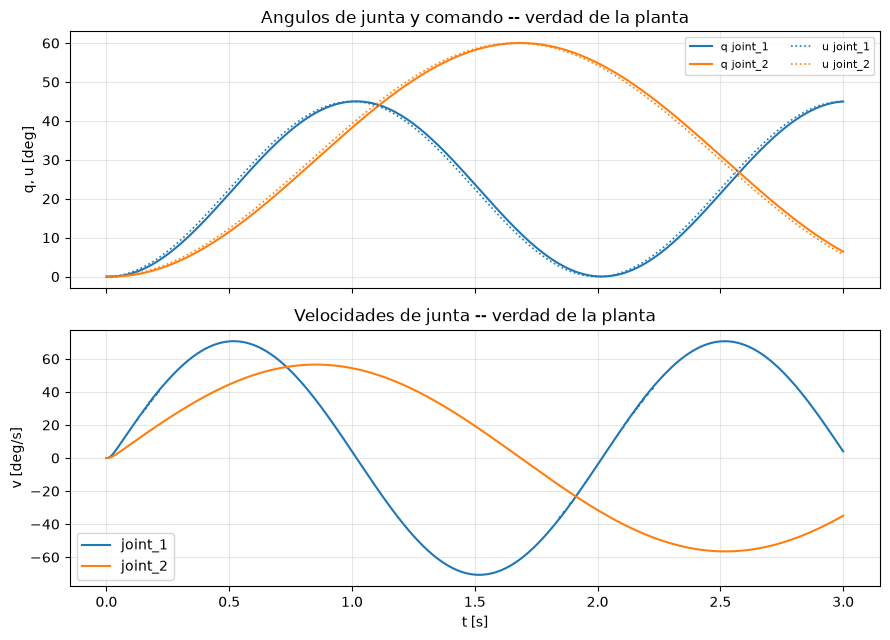

In [36]:
# ============================================================================
# FIGURA 1 -- ESTADO de la planta
# ============================================================================
# X_t es [q, v, a] en BLOQUES, no intercalado. El angulo y el comando van juntos
# porque comparten unidad y escala (los dos en rad -> grados); la velocidad va en
# su propio panel, si no su pico (~1.4 rad/s) aplasta a los otros.
nv, nu = model_sim.nv, model_sim.nu
joint_names = [model_sim.joint(int(model_sim.dof_jntid[j])).name for j in range(nv)]

fig_x, (ax_q, ax_v) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)

# --- 1. ANGULOS q y comando u ----------------------------------------------
# X_t y T_t tienen los dos n+1 muestras -> se grafican enteros, ya alineados.
# U_t tiene n muestras -- actua DURANTE el paso [t_k, t_{k+1}] -> va contra
# T_t[:-1]. Contra T_t entero ni siquiera cierran las longitudes.
for j in range(nv):
    ax_q.plot(T_t, np.rad2deg(X_t[:, j]), color=f"C{j}",
              label=f"q {joint_names[j]}")
for j in range(nu):
    ax_q.plot(T_t[:-1], np.rad2deg(U_t[:, j]), color=f"C{j}", ls=":", lw=1.2,
              label=f"u {joint_names[j]}")
ax_q.set_title("Angulos de junta y comando -- verdad de la planta")
ax_q.set_ylabel("q, u [deg]")
ax_q.grid(True, alpha=0.3)
ax_q.legend(ncol=2, fontsize=8)

# --- 2. VELOCIDADES v -------------------------------------------------------
for j in range(nv):
    ax_v.plot(T_t, np.rad2deg(X_t[:, nv + j]), color=f"C{j}",
              label=joint_names[j])
ax_v.set_title("Velocidades de junta -- verdad de la planta")
ax_v.set_ylabel("v [deg/s]")
ax_v.grid(True, alpha=0.3)
ax_v.legend()

ax_v.set_xlabel("t [s]")     # sharex=True -> solo el panel de abajo lo lleva
fig_x.tight_layout()
plt.show()

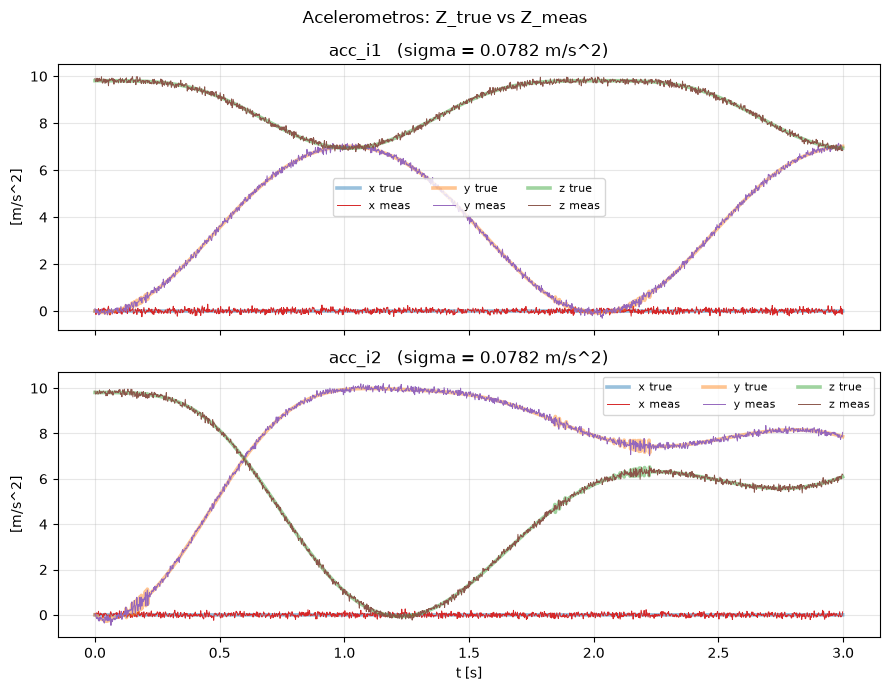

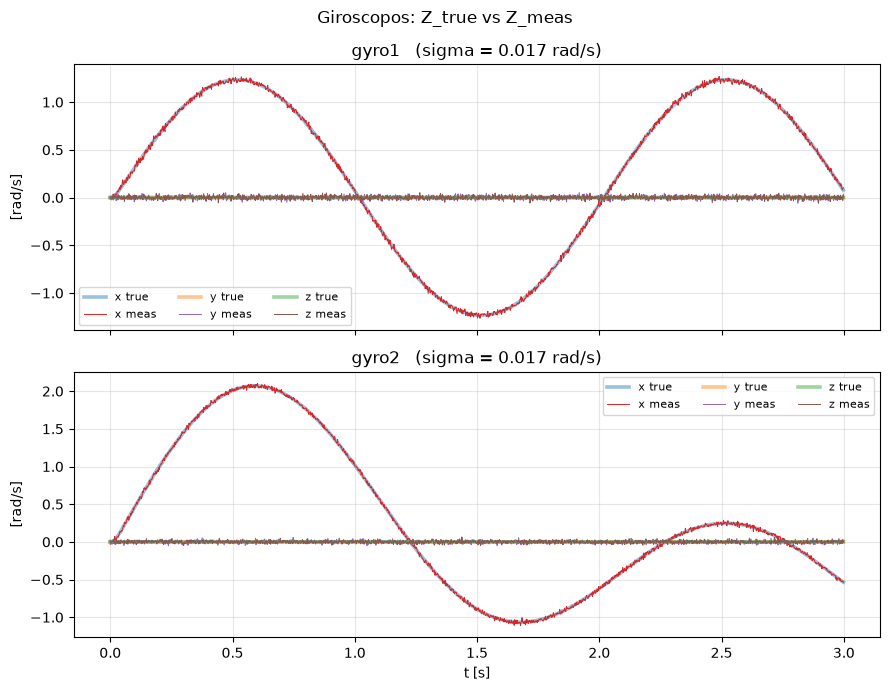

In [37]:
# ============================================================================
# FIGURAS 2 y 3 -- SENSOR: Z_true (ideal) vs Z_meas (ruidosa)
# ============================================================================
# Las dos son la MISMA trayectoria: sensor_noise no toca el estado, solo lo que se
# lee de el, asi que toda la diferencia entre las curvas es ruido blanco de sigma
# conocido (SIG_ACC / SIG_GYR) y nada mas.
# Z_true y Z_meas tienen n muestras, igual que U_t -> van contra T_t[:-1].
#
# Un COLOR POR TRAZA, no por eje: sigma vale entre 0.2% (gyro) y 1.7% (acc) del
# recorrido del canal, asi que las dos curvas caen practicamente una encima de la
# otra y con el mismo color no hay forma de saber cual es cual. La verdad va como
# banda ancha y semitransparente, la medicion como linea fina y opaca encima ->
# la traza fina de arriba es siempre Z_meas.
# Los TRES ejes de cada sensor, no solo los activos: los hinges giran en x, asi que
# acc_*_x y gyro*_{y,z} son cero en la verdad, y ahi el ruido es lo unico que hay.
SIGMAS = np.sqrt(np.diag(make_R(model_sim, SIG_ACC, SIG_GYR)))
COLOR_TRUE = ("C0", "C1", "C2")     # x, y, z de Z_true
COLOR_MEAS = ("C3", "C4", "C5")     # x, y, z de Z_meas


def plot_sensor(ax, name, unit):
    """Panel de un sensor: sus tres ejes, Z_true (banda ancha) y Z_meas (fino).

    name : nombre del sensor en el XML; las filas salen de sensor_slice, nunca de
           un indice absoluto en sensordata.
    unit : unidad del sensor, para el eje y (m/s^2 o rad/s).
    """
    sl = sensor_slice(name, model_sim)
    for k, row in enumerate(range(sl.start, sl.stop)):
        axis = "xyz"[k]
        ax.plot(T_t[:-1], Z_true[:, row], color=COLOR_TRUE[k], lw=2.6, alpha=0.45,
                label=f"{axis} true")
        ax.plot(T_t[:-1], Z_meas[:, row], color=COLOR_MEAS[k], lw=0.7,
                label=f"{axis} meas")
    ax.set_title(f"{name}   (sigma = {SIGMAS[sl.start]:g} {unit})")
    ax.set_ylabel(f"[{unit}]")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, fontsize=8)


# --- FIGURA 2: los dos acelerometros ----------------------------------------
fig_acc, axes_acc = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, name in zip(axes_acc, ("acc_i1", "acc_i2")):
    plot_sensor(ax, name, "m/s^2")
axes_acc[-1].set_xlabel("t [s]")
fig_acc.suptitle("Acelerometros: Z_true vs Z_meas")
fig_acc.tight_layout()
plt.show()

# --- FIGURA 3: los dos giroscopos -------------------------------------------
fig_gyr, axes_gyr = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, name in zip(axes_gyr, ("gyro1", "gyro2")):
    plot_sensor(ax, name, "rad/s")
axes_gyr[-1].set_xlabel("t [s]")
fig_gyr.suptitle("Giroscopos: Z_true vs Z_meas")
fig_gyr.tight_layout()
plt.show()

In [38]:
t0 = time.perf_counter()
filter_results = run_filter(model_blind,X_t,Z_meas)
print(f"\nEl filtro corrio en -- {time.perf_counter() - t0:.1f} s")
filter_results.keys()


El filtro corrio en -- 0.8 s


dict_keys(['nees', 'nis', 'err', 'sig', 'xh', 'innov', 'z_pred', 'nx', 'model', 'rows'])

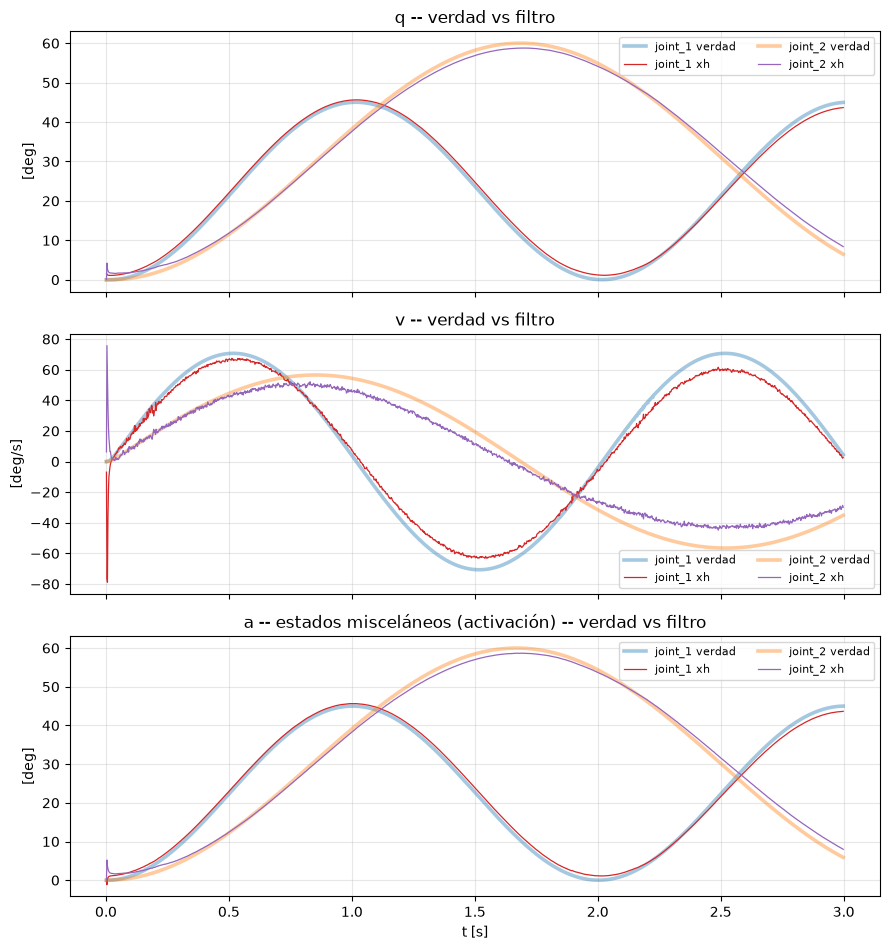

In [39]:
# ============================================================================
# FIGURA -- ESTADO: X_t (verdad de la planta) vs xh (estimacion del filtro)
# ============================================================================
# xh arranca en k=1 (run_filter no reporta el prior, solo posteriores) y tiene
# len(Z)-1 muestras -> el eje de tiempo es T_t[1:1+N], no T_t completo.
#
# La verdad se compara vs Xr = blind_reference(X_t, model), no vs X_t crudo: en
# el bloque de activacion X_t[k] es a_k, pero el filtro ciego carga la activacion
# EN VIGOR durante el paso, que es a_{k+1} (ver blind_reference / run_filter mas
# arriba). Comparar contra X_t crudo metería medio paso de desfasaje fantasma en
# el panel de activacion. En q y v, Xr es identico a X_t -- blind_reference solo
# toca el bloque de activacion.
#
# Colores: verdad = paleta ancha/palida, estimacion = paleta fina/opaca -- mismo
# convenio que las figuras de sensor de arriba, para que las dos curvas nunca
# compartan color.
model = filter_results["model"]
nx = filter_results["nx"]
nv, na = model.nv, model.na
xh = filter_results["xh"]
N = len(xh)
t_est = T_t[1:1 + N]

Xr = blind_reference(X_t, model)[1:1 + N]

COLOR_TRUE = ("C0", "C1")
COLOR_EST = ("C3", "C4")

n_panels = 2 + (1 if na else 0)
fig_xh, axes = plt.subplots(n_panels, 1, figsize=(9, 3.2 * n_panels), sharex=True)

blocks = [("q", "deg", 0, nv), ("v", "deg/s", nv, 2 * nv)]
if na:
    blocks.append(("a -- estados misceláneos (activación)", "deg", 2 * nv, 2 * nv + na))

for ax, (label, unit, lo, hi) in zip(axes, blocks):
    for j in range(hi - lo):
        ax.plot(t_est, np.rad2deg(Xr[:, lo + j]), color=COLOR_TRUE[j], lw=2.6,
                alpha=0.4, label=f"{joint_names[j]} verdad")
        ax.plot(t_est, np.rad2deg(xh[:, lo + j]), color=COLOR_EST[j], lw=0.9,
                label=f"{joint_names[j]} xh")
    ax.set_title(f"{label} -- verdad vs filtro")
    ax.set_ylabel(f"[{unit}]")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

axes[-1].set_xlabel("t [s]")
fig_xh.tight_layout()
plt.show()

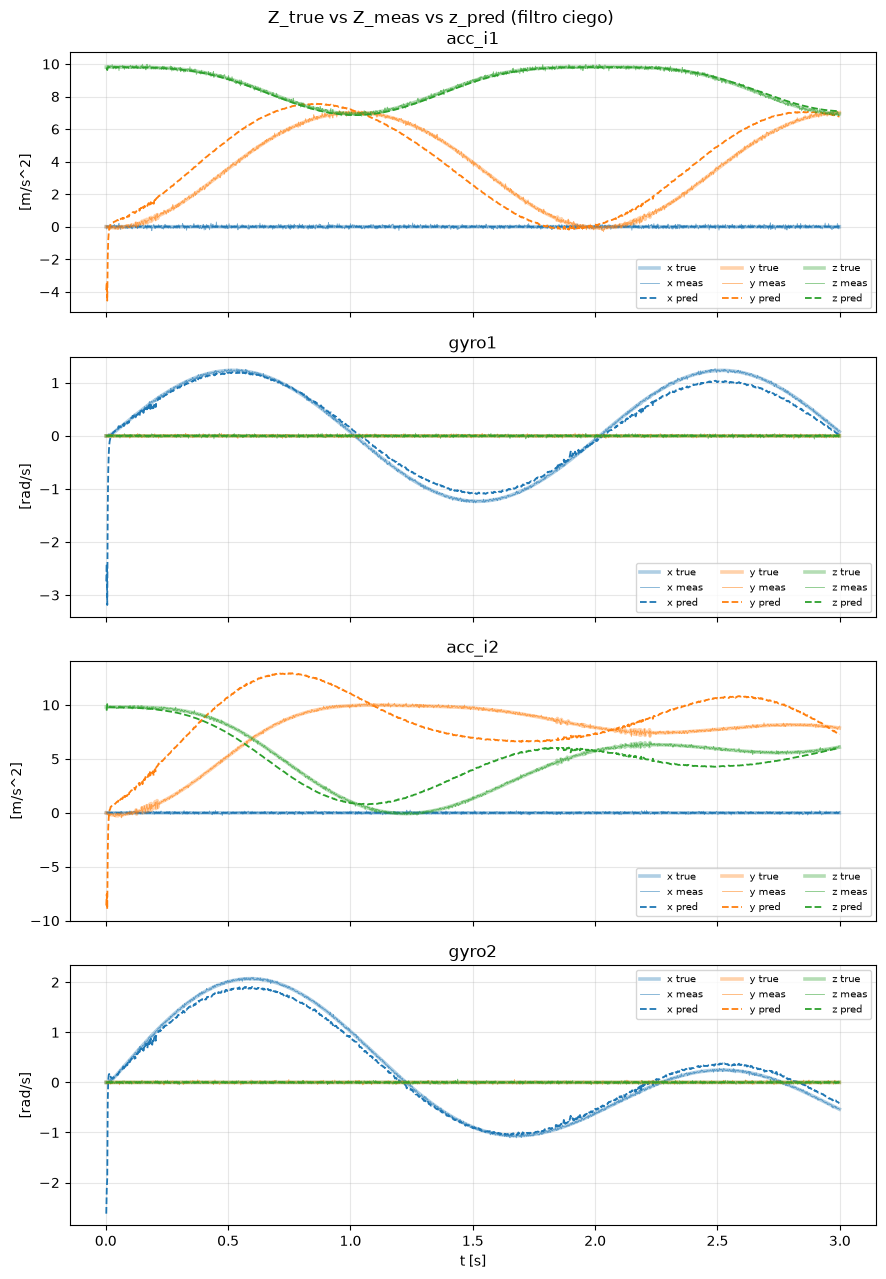

In [40]:
# ============================================================================
# FIGURA -- SENSOR: Z_true, Z_meas y z_pred (lo que el filtro creia leer)
# ============================================================================
# z_pred = filter_results["z_pred"] solo existe para las filas de ROWS (el IMU),
# y con N = len(Z)-1 muestras -- mismo desfasaje de indice que xh, por la misma
# razon (run_filter no reporta el prior). Para comparar los tres en el mismo
# instante, Z_true/Z_meas se recortan a la MISMA ventana t_est en vez de a su
# rango completo T_t[:-1].
#
# row_to_col mapea una fila absoluta de sensordata a su columna dentro de
# z_pred, en vez de asumir un orden -- z_pred sigue el orden de ROWS = rows_of(*IMU).
row_to_col = {row: i for i, row in enumerate(ROWS)}
z_pred = filter_results["z_pred"]

Z_true_c = Z_true[1:1 + N]
Z_meas_c = Z_meas[1:1 + N]

COLOR_AXIS = ("C0", "C1", "C2")   # x, y, z -- mismo color en las tres trazas


def plot_sensor_pred(ax, name, unit):
    """Los tres ejes de un sensor: Z_true (banda), Z_meas (fina), z_pred (punteada).

    name : nombre del sensor en el XML; las filas salen de sensor_slice, nunca de
           un indice absoluto en sensordata.
    """
    sl = sensor_slice(name, model_sim)
    for k, row in enumerate(range(sl.start, sl.stop)):
        axis, color = "xyz"[k], COLOR_AXIS[k]
        ax.plot(t_est, Z_true_c[:, row], color=color, lw=2.6, alpha=0.35,
                label=f"{axis} true")
        ax.plot(t_est, Z_meas_c[:, row], color=color, lw=0.6, alpha=0.6,
                label=f"{axis} meas")
        ax.plot(t_est, z_pred[:, row_to_col[row]], color=color, lw=1.3, ls="--",
                label=f"{axis} pred")
    ax.set_title(name)
    ax.set_ylabel(f"[{unit}]")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, fontsize=7)


fig_zp, axes_zp = plt.subplots(4, 1, figsize=(9, 13), sharex=True)
for ax, (name, unit) in zip(axes_zp, (("acc_i1", "m/s^2"), ("gyro1", "rad/s"),
                                      ("acc_i2", "m/s^2"), ("gyro2", "rad/s"))):
    plot_sensor_pred(ax, name, unit)
axes_zp[-1].set_xlabel("t [s]")
fig_zp.suptitle("Z_true vs Z_meas vs z_pred (filtro ciego)")
fig_zp.tight_layout()
plt.show()